# NeuroStat
## EEG Feature Engineering, PCA, Clustering, and Anomaly Detection

이 노트북은 HMS EEG 데이터를 이용해 **EEG 파일별 통계 feature를 추출**하고,  
추출한 feature를 바탕으로 **PCA 시각화, K-Means 클러스터링, Isolation Forest 이상 탐지**를 수행하는 흐름이다.

전체 흐름은 다음과 같다.

1. `train.csv`와 EEG parquet 파일 구조 확인
2. EEG 채널 및 라벨 분포 탐색
3. 환자 단위 train/validation/test 분할 확인
4. EEG 파일별 통계 feature 추출
5. 결측치 처리 및 표준화
6. PCA로 차원 축소 후 패턴 시각화
7. K-Means로 군집 구조 확인
8. Isolation Forest로 이상 EEG 탐지
9. artifact가 강한 EEG를 확인한 뒤 feature 정제 재수행


## 1. 데이터 기본 확인

가장 먼저 `train.csv`를 불러와 데이터 크기와 클래스 분포를 확인한다.  
`expert_consensus`는 전문가가 판단한 EEG 유형으로, 이후 PCA/클러스터 결과를 해석할 때 기준 라벨로 사용된다.


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Jupyter plotting backend
%matplotlib inline

# 1. CSV 로드 (가볍게 시작)
df = pd.read_csv('/Users/pitzsb1/Documents/HBAC/train.csv')


print(df.shape)
print(df['expert_consensus'].value_counts())  # 클래스 분포 확인
print(df.head())

(106800, 15)
expert_consensus
Seizure    20933
GRDA       18861
Other      18808
GPD        16702
LRDA       16640
LPD        14856
Name: count, dtype: int64
       eeg_id  eeg_sub_id  eeg_label_offset_seconds  spectrogram_id  \
0  1628180742           0                       0.0          353733   
1  1628180742           1                       6.0          353733   
2  1628180742           2                       8.0          353733   
3  1628180742           3                      18.0          353733   
4  1628180742           4                      24.0          353733   

   spectrogram_sub_id  spectrogram_label_offset_seconds    label_id  \
0                   0                               0.0   127492639   
1                   1                               6.0  3887563113   
2                   2                               8.0  1142670488   
3                   3                              18.0  2718991173   
4                   4                              24.0  308

### 1.1 EEG parquet 파일 한 개 확인

`train.csv`의 첫 번째 `eeg_id`를 이용해 실제 EEG parquet 파일을 열어본다.  
이 단계의 목적은 EEG 파일이 몇 개의 시점과 채널로 구성되어 있는지 확인하는 것이다.


(18000, 20)
['Fp1', 'F3', 'C3', 'P3', 'F7', 'T3', 'T5', 'O1', 'Fz', 'Cz', 'Pz', 'Fp2', 'F4', 'C4', 'P4', 'F8', 'T4', 'T6', 'O2', 'EKG']


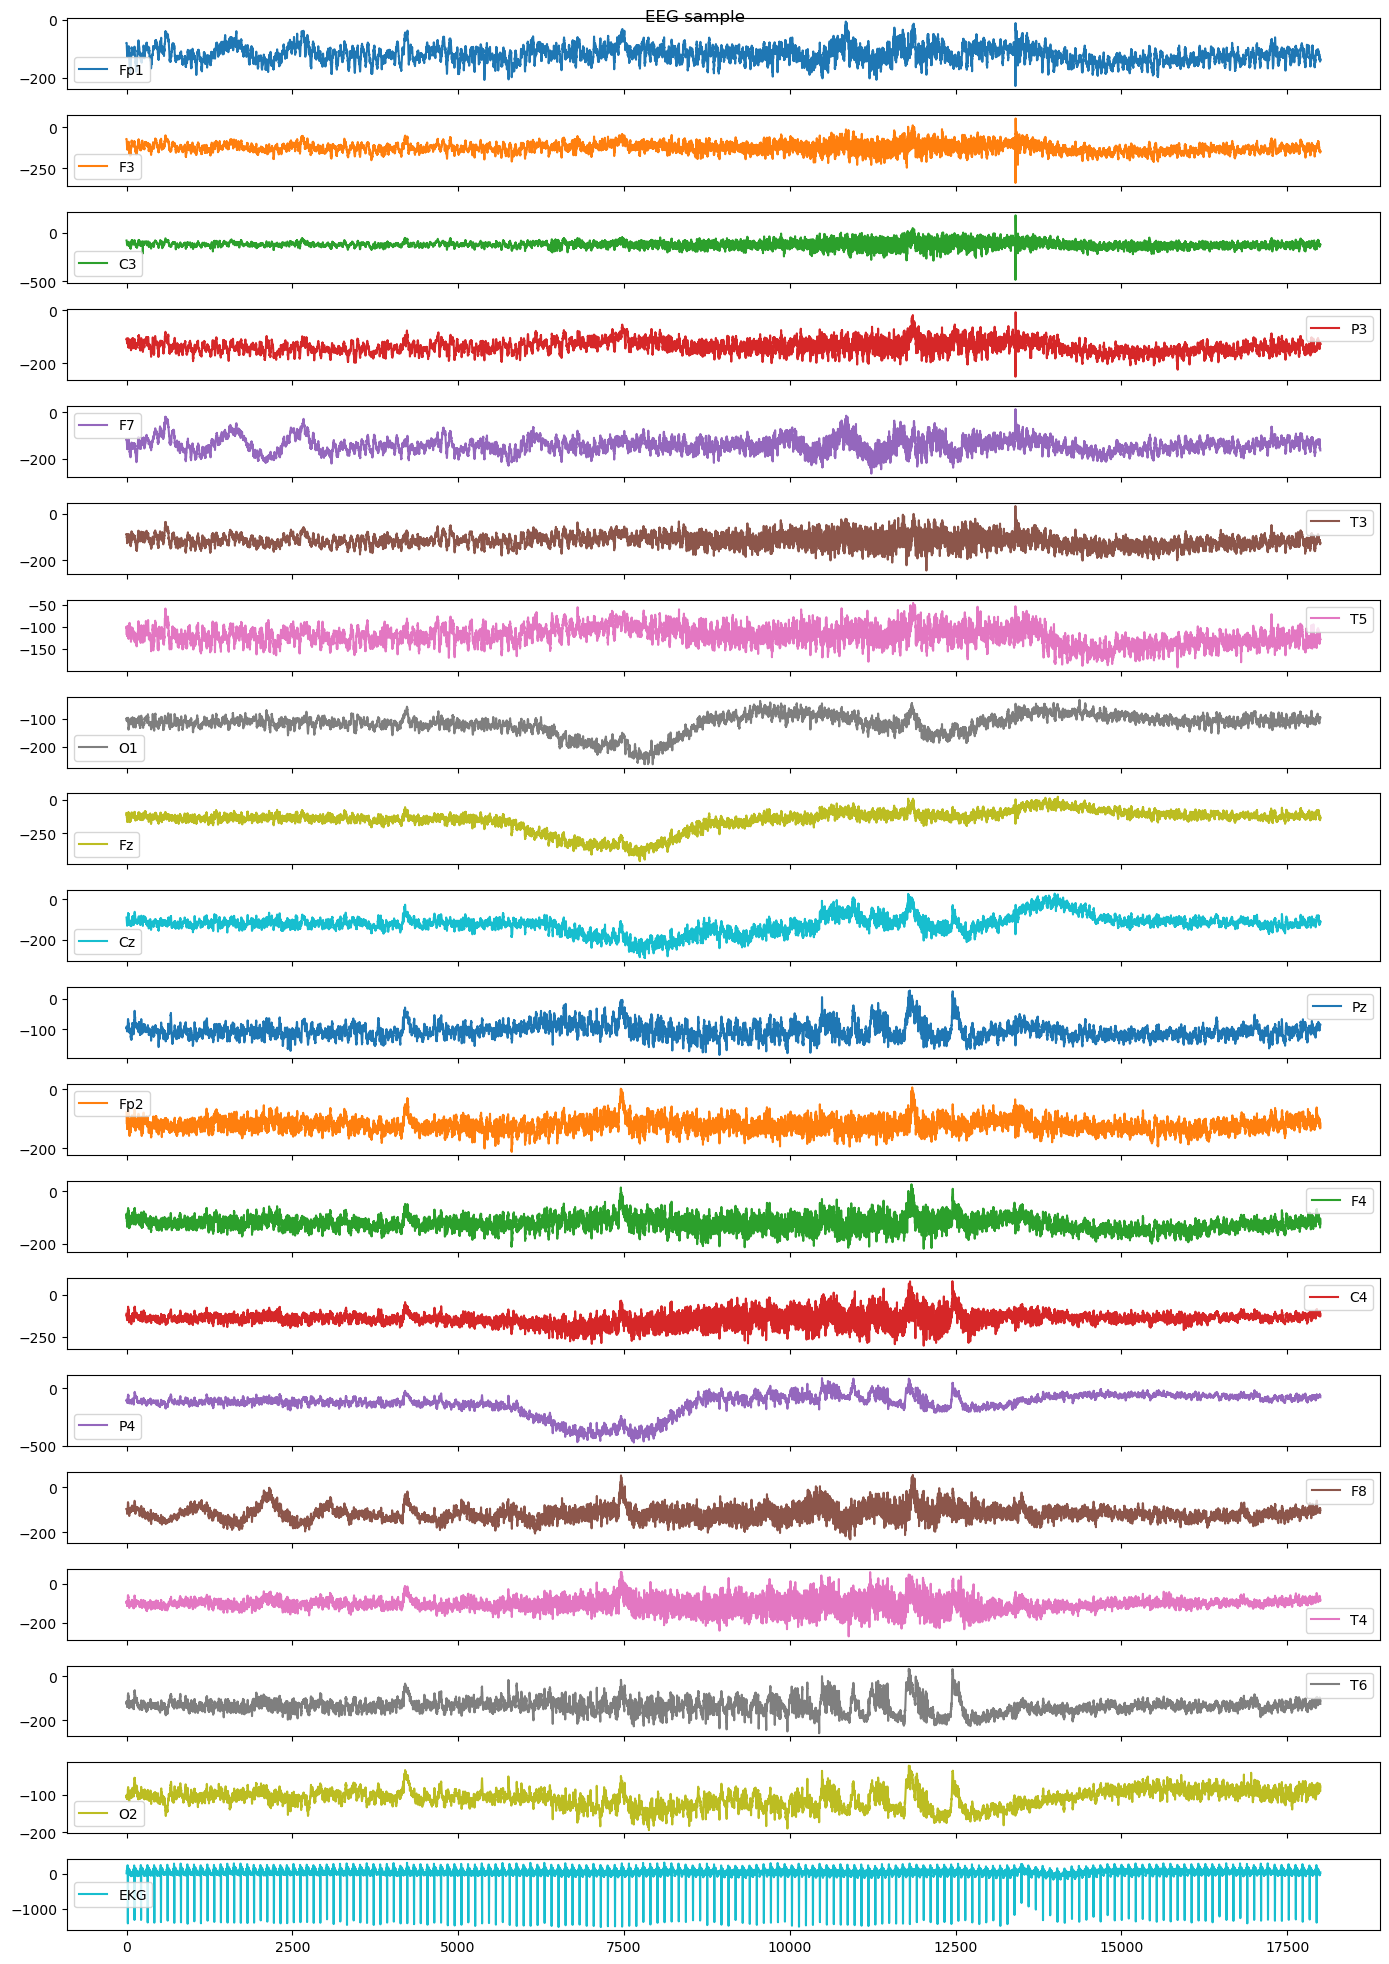

In [19]:
# 하나만 먼저 탐색
sample_id = df['eeg_id'].iloc[0]
eeg = pd.read_parquet(f'/Users/pitzsb1/Documents/train_eegs/{sample_id}.parquet')

print(eeg.shape) # (시간축 길이, 20채널)
print(eeg.columns.tolist())
eeg.plot(subplots=True, figsize=(14, 20), title='EEG sample')
plt.tight_layout()
plt.show()

### 1.2 특정 EEG 파일 상세 구조 확인

하나의 EEG 파일을 고정해서 열고, column 이름, 데이터 타입, 앞부분 값, 기초 통계를 확인한다.  
이 과정을 통해 각 채널 값의 범위와 결측 여부를 대략적으로 파악할 수 있다.


In [20]:
import pandas as pd

# 하나만 먼저 열기
eeg = pd.read_parquet('/Users/pitzsb1/Documents/train_eegs/1000913311.parquet')

print("Shape:", eeg.shape)          # (행 수=시간축, 열 수=채널)
print("\nColumns:", eeg.columns.tolist())
print("\nDtype:\n", eeg.dtypes)
print("\n앞부분:\n", eeg.head())
print("\n기초 통계:\n", eeg.describe())

Shape: (10000, 20)

Columns: ['Fp1', 'F3', 'C3', 'P3', 'F7', 'T3', 'T5', 'O1', 'Fz', 'Cz', 'Pz', 'Fp2', 'F4', 'C4', 'P4', 'F8', 'T4', 'T6', 'O2', 'EKG']

Dtype:
 Fp1    float32
F3     float32
C3     float32
P3     float32
F7     float32
T3     float32
T5     float32
O1     float32
Fz     float32
Cz     float32
Pz     float32
Fp2    float32
F4     float32
C4     float32
P4     float32
F8     float32
T4     float32
T6     float32
O2     float32
EKG    float32
dtype: object

앞부분:
           Fp1          F3         C3         P3          F7          T3  \
0 -105.849998  -89.230003 -79.459999 -49.230000  -99.730003  -87.769997   
1  -85.470001  -75.070000 -60.259998 -38.919998  -73.080002  -87.510002   
2    8.840000   34.849998  56.430000  67.970001   48.099998   25.350000   
3  -56.320000  -37.279999 -28.100000  -2.820000  -43.430000  -35.049999   
4 -110.139999 -104.519997 -96.879997 -70.250000 -111.660004 -114.430000   

          T5         O1         Fz         Cz         Pz        Fp

# 1. Data Loading

HMS EEG 데이터를 불러온다.

- EEG parquet 파일 로드
- EKG 채널 제외
- 기본 구조 확인

## 2. EEG 신호 시각화

이 단계에서는 특정 EEG 파일의 채널별 파형을 직접 그려본다.  
EKG는 심전도 신호이므로 EEG 패턴 분석에서는 제외하고, 순수 EEG 채널만 시각화한다.


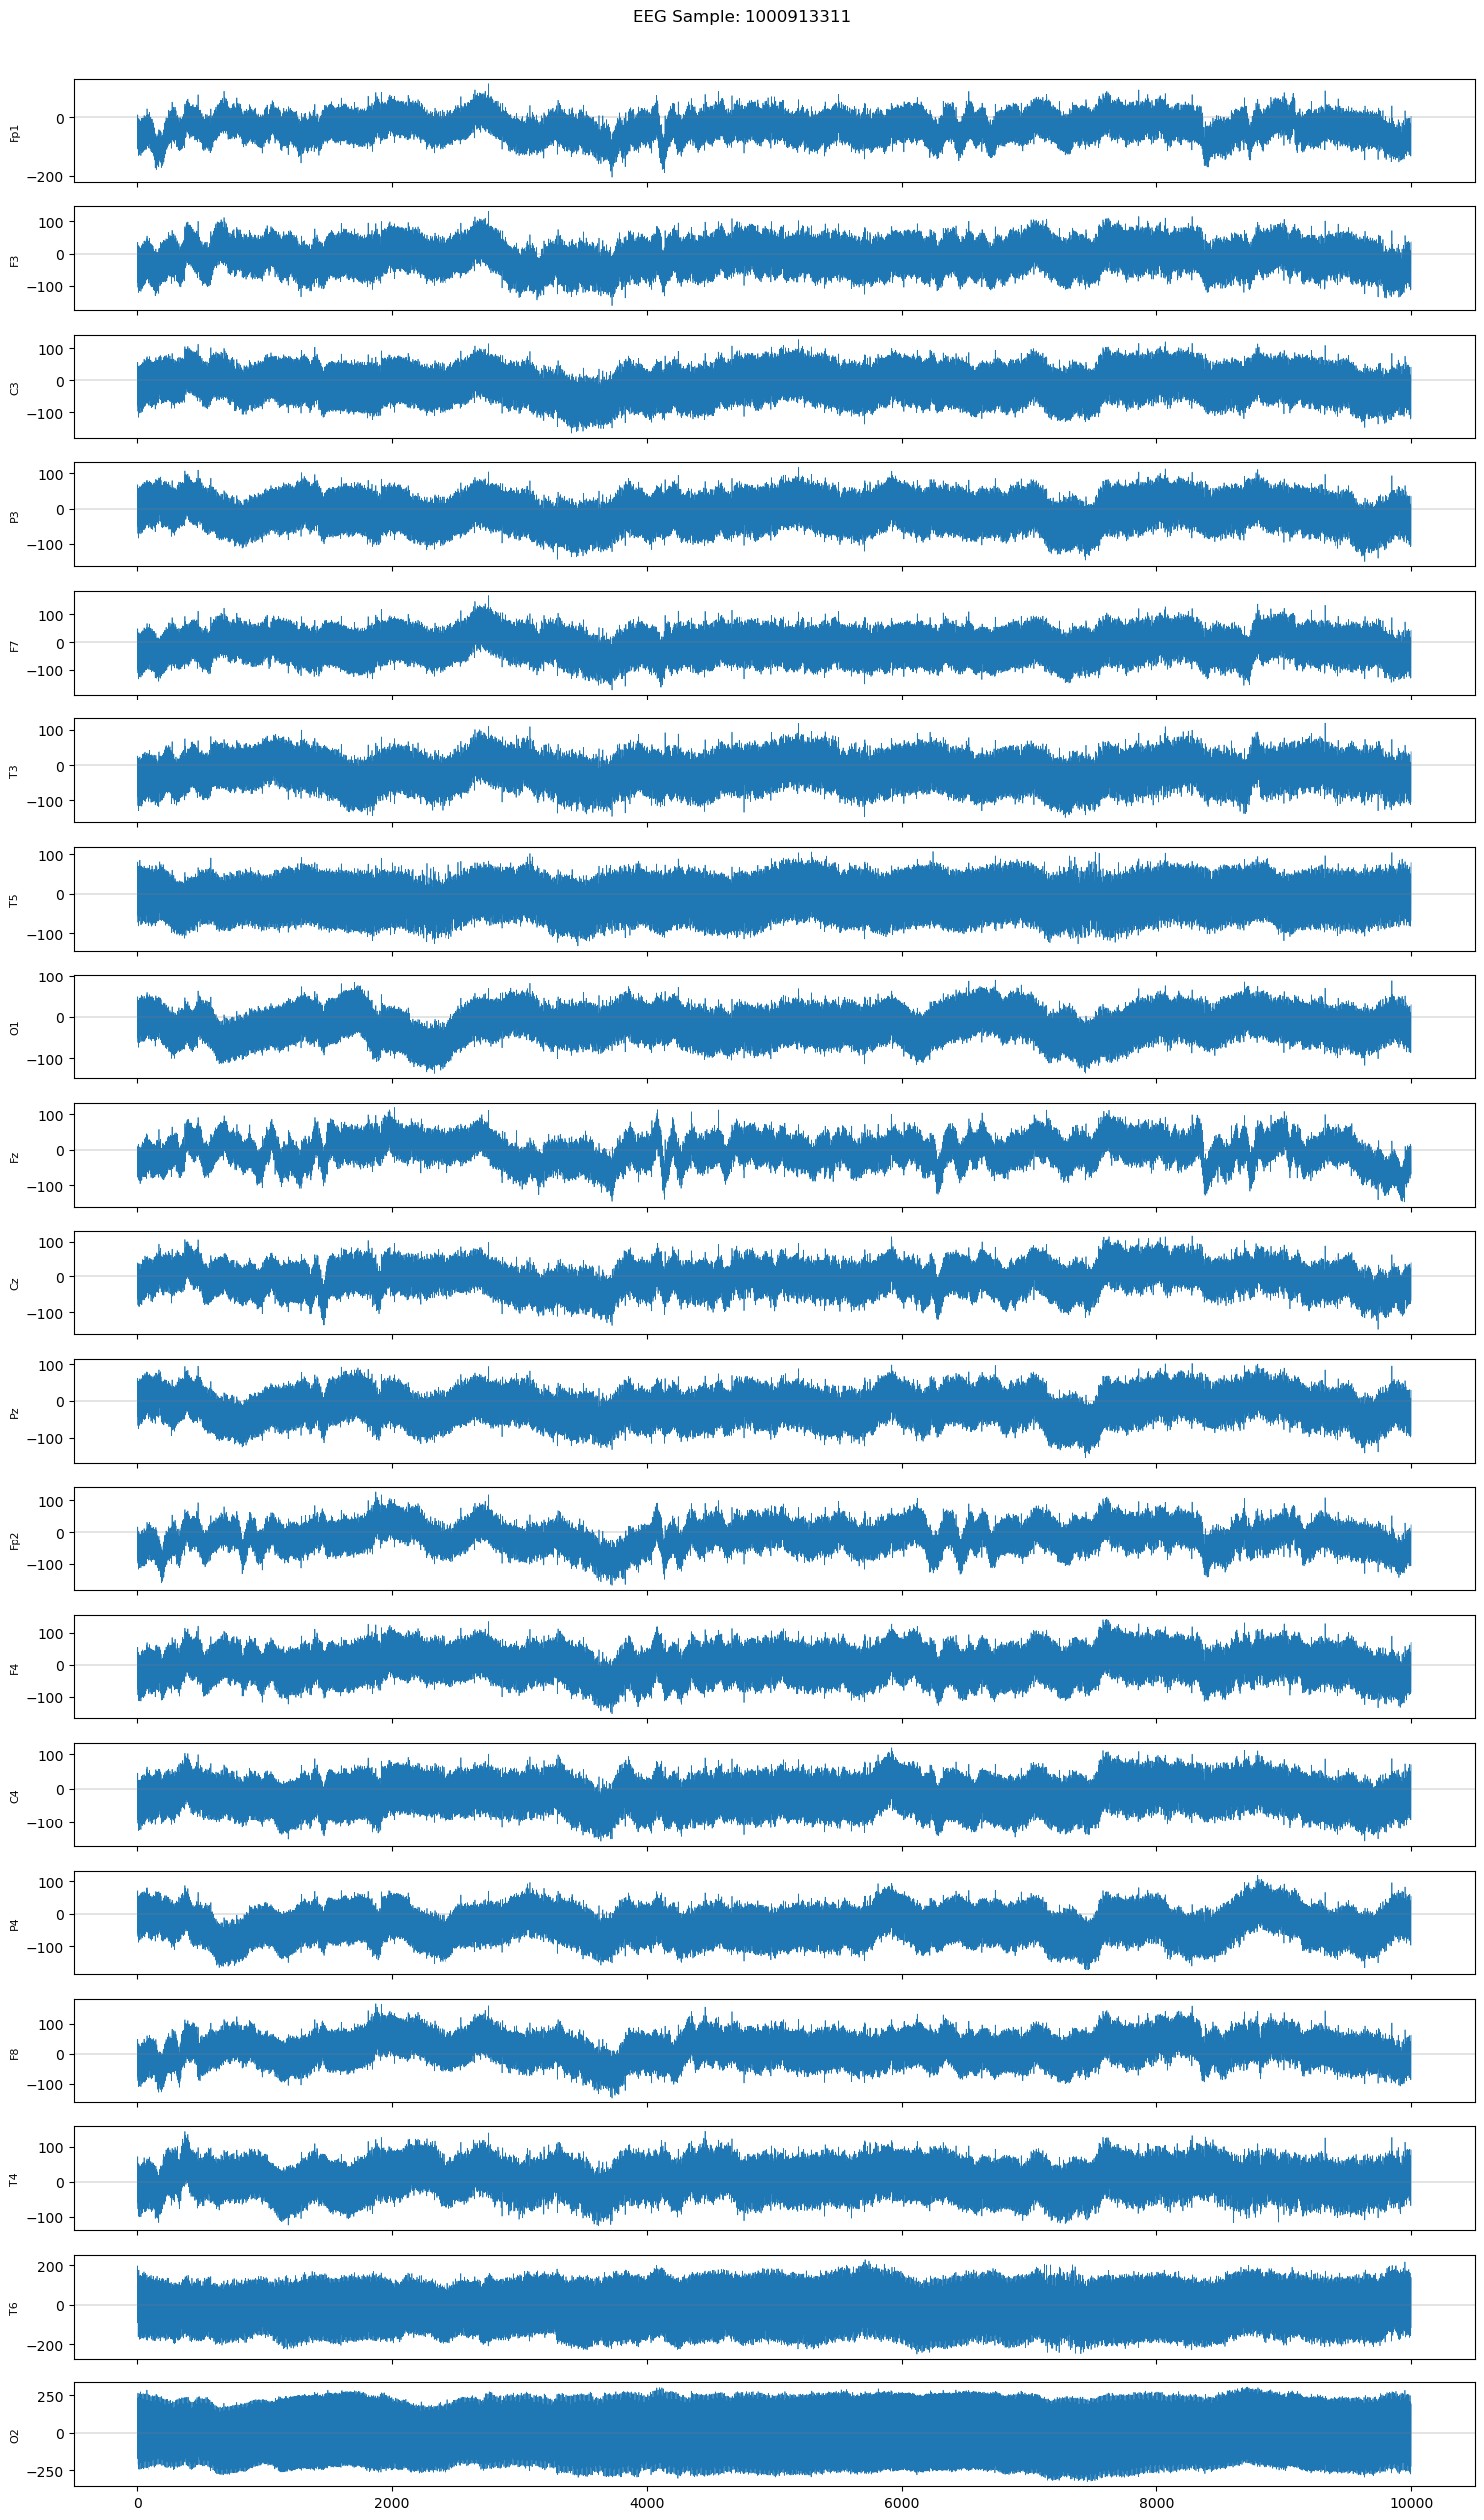

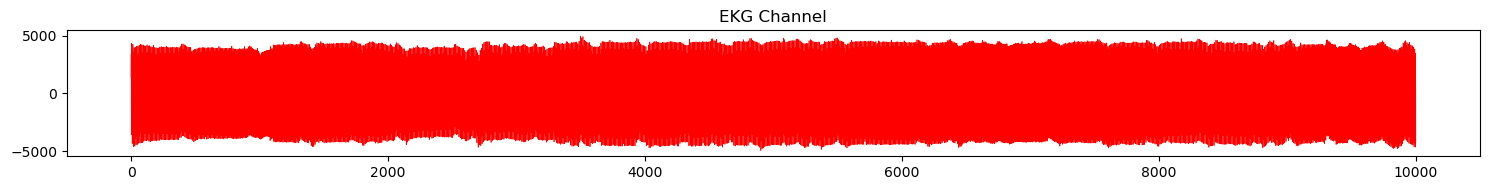

In [21]:
import matplotlib.pyplot as plt

eeg = pd.read_parquet('/Users/pitzsb1/Documents/train_eegs/1000913311.parquet')

# EEG 채널만 (EKG 제외)
eeg_channels = [c for c in eeg.columns if c != 'EKG']

fig, axes = plt.subplots(len(eeg_channels), 1, figsize=(15, 25), sharex=True)

for i, ch in enumerate(eeg_channels):
    axes[i].plot(eeg[ch].values, linewidth=0.5)
    axes[i].set_ylabel(ch, fontsize=8)
    axes[i].axhline(0, color='gray', linewidth=0.3)

plt.suptitle('EEG Sample: 1000913311', y=1.01)
plt.tight_layout()
plt.show()

# EKG 별도 시각화
plt.figure(figsize=(15, 2))
plt.plot(eeg['EKG'].values, linewidth=0.5, color='red')
plt.title('EKG Channel')
plt.tight_layout()
plt.show()

### 2.1 해당 EEG의 라벨 정보 확인

시각화한 EEG가 어떤 전문가 라벨과 vote 분포를 갖는지 확인한다.  
신호 모양과 라벨을 함께 보면 이후 이상 패턴을 해석할 때 도움이 된다.


In [22]:
df = pd.read_csv('/Users/pitzsb1/Documents/HBAC/train.csv')
print(df[df['eeg_id'] == 1000913311][['eeg_id', 'expert_consensus', 'seizure_vote', 'lpd_vote', 'gpd_vote', 'lrda_vote', 'grda_vote', 'other_vote']])

          eeg_id expert_consensus  seizure_vote  lpd_vote  gpd_vote  \
9529  1000913311            Other             0         0         0   

      lrda_vote  grda_vote  other_vote  
9529          0          0           2  


## 3. 메타데이터 EDA

`train.csv` 전체의 크기, 클래스 분포, 결측치를 확인한다.  
비지도학습을 하더라도 라벨 분포를 알고 있으면 결과 해석에 유리하다.


In [23]:
import pandas as pd

df = pd.read_csv('/Users/pitzsb1/Documents/HBAC/train.csv')

print("Shape:", df.shape)
print("\n클래스 분포:")
print(df['expert_consensus'].value_counts())
print("\n결측치:")
print(df.isnull().sum())
print("\n앞부분:")
print(df.head())

Shape: (106800, 15)

클래스 분포:
expert_consensus
Seizure    20933
GRDA       18861
Other      18808
GPD        16702
LRDA       16640
LPD        14856
Name: count, dtype: int64

결측치:
eeg_id                              0
eeg_sub_id                          0
eeg_label_offset_seconds            0
spectrogram_id                      0
spectrogram_sub_id                  0
spectrogram_label_offset_seconds    0
label_id                            0
patient_id                          0
expert_consensus                    0
seizure_vote                        0
lpd_vote                            0
gpd_vote                            0
lrda_vote                           0
grda_vote                           0
other_vote                          0
dtype: int64

앞부분:
       eeg_id  eeg_sub_id  eeg_label_offset_seconds  spectrogram_id  \
0  1628180742           0                       0.0          353733   
1  1628180742           1                       6.0          353733   
2  1628180742     

### 3.1 단일 EEG 라벨 재확인

특정 `eeg_id`의 라벨과 각 클래스 vote를 다시 확인한다.  
동일한 EEG 파일이 어떤 전문가 합의 라벨을 받았는지 명확히 기록하기 위한 단계다.


In [24]:
eeg_id = 1000913311
label_info = df[df['eeg_id'] == eeg_id][['eeg_id', 'expert_consensus', 'seizure_vote', 'lpd_vote', 'gpd_vote', 'lrda_vote', 'grda_vote', 'other_vote']]
print(label_info)

          eeg_id expert_consensus  seizure_vote  lpd_vote  gpd_vote  \
9529  1000913311            Other             0         0         0   

      lrda_vote  grda_vote  other_vote  
9529          0          0           2  


## 4. 클래스별 대표 EEG 샘플 선택

각 `expert_consensus` 클래스에서 대표 EEG 파일을 하나씩 선택한다.  
이후 같은 채널의 파형을 비교해서 클래스별 신호 차이가 눈으로 보이는지 확인한다.


In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import os

df = pd.read_csv('/Users/pitzsb1/Documents/HBAC/train.csv')

# 클래스별 대표 eeg_id 하나씩 뽑기
classes = ['Seizure', 'GPD', 'LPD', 'GRDA', 'LRDA', 'Other']
samples = {}
for cls in classes:
    row = df[df['expert_consensus'] == cls].iloc[0]
    samples[cls] = row['eeg_id']

print("클래스별 샘플 eeg_id:")
for cls, eid in samples.items():
    print(f"  {cls}: {eid}")

클래스별 샘플 eeg_id:
  Seizure: 1628180742
  GPD: 2277392603
  LPD: 736446371
  GRDA: 2578018731
  LRDA: 722738444
  Other: 1202099836


### 4.1 클래스별 Fz 채널 파형 비교

모든 채널을 한 번에 비교하면 복잡하므로, 먼저 `Fz` 채널 하나만 사용해 클래스별 파형을 비교한다.  
여기서는 분류 모델을 만드는 것이 아니라, 라벨별 EEG 모양이 얼마나 다른지 탐색하는 목적이다.


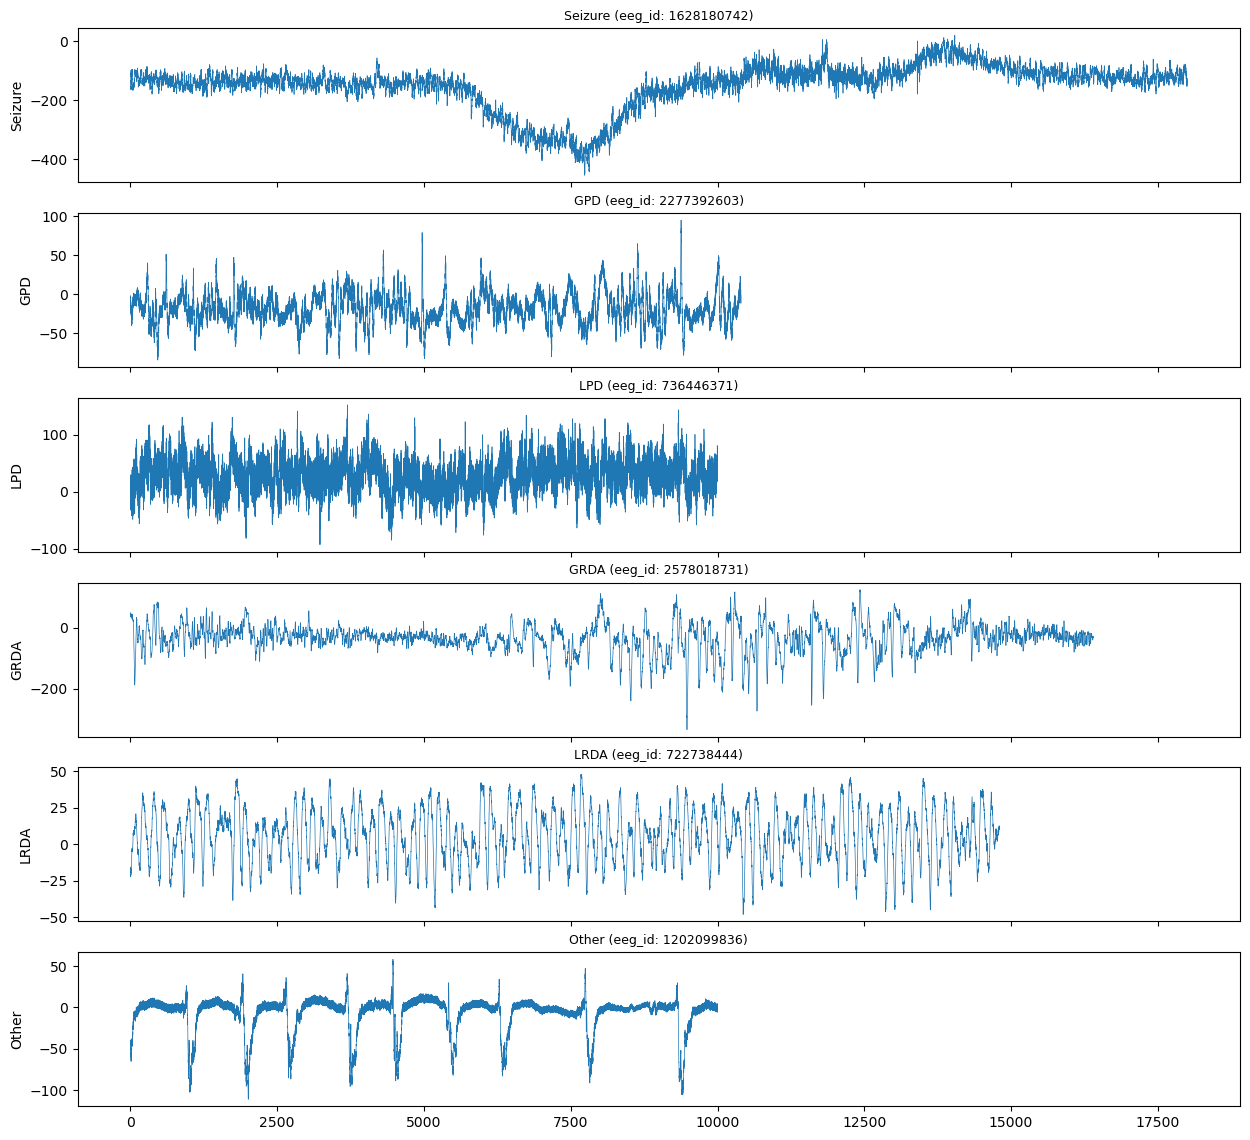

<Figure size 640x480 with 0 Axes>

In [26]:
# 클래스별 신호 비교 시각화 (Fz 채널 하나만)
fig, axes = plt.subplots(6, 1, figsize=(15, 14), sharex=True)

for i, (cls, eid) in enumerate(samples.items()):
    path = f'/Users/pitzsb1/Documents/train_eegs/{eid}.parquet'
    if os.path.exists(path):
        eeg = pd.read_parquet(path)
        axes[i].plot(eeg['Fz'].values, linewidth=0.5)
        axes[i].set_ylabel(cls, fontsize=10)
        axes[i].set_title(f'{cls} (eeg_id: {eid})', fontsize=9)
    else:
        axes[i].text(0.5, 0.5, 'Missing file', ha='center', va='center', fontsize=12, color='red')
        axes[i].set_ylabel(cls, fontsize=10)
        axes[i].set_title(f'{cls} (missing: {eid})', fontsize=9)

plt.show()

plt.suptitle('클래스별 EEG 신호 비교 (Fz 채널)', fontsize=13)
plt.tight_layout()

## 5. 파일 개수와 고유 EEG 수 확인

실제 parquet 파일 수와 `train.csv`에 기록된 고유 `eeg_id` 수를 비교한다.  
두 값이 크게 다르면 일부 파일이 없거나 메타데이터와 EEG 파일 간 매칭 문제가 있을 수 있다.


In [27]:
import os
files = [f for f in os.listdir('/Users/pitzsb1/Documents/train_eegs/') if f.endswith('.parquet')]
print(f"전체 parquet 파일 수: {len(files)}")

# train.csv의 고유 eeg_id 수와 비교
print(f"train.csv 고유 eeg_id 수: {df['eeg_id'].nunique()}")

전체 parquet 파일 수: 17300
train.csv 고유 eeg_id 수: 17089


## 6. 환자 단위 데이터 분할

EEG 데이터에서는 같은 환자의 신호가 train과 test에 동시에 들어가면 데이터 누수가 생길 수 있다.  
따라서 행 단위가 아니라 `patient_id` 기준으로 train/validation/test를 나눈다.


In [28]:
from sklearn.model_selection import train_test_split

patients = df['patient_id'].unique()

# 환자 기준으로 분할 (train 70 / val 15 / test 15)
train_pts, temp_pts = train_test_split(patients, test_size=0.3, random_state=42)
val_pts, test_pts = train_test_split(temp_pts, test_size=0.5, random_state=42)

train_df = df[df['patient_id'].isin(train_pts)]
val_df   = df[df['patient_id'].isin(val_pts)]
test_df  = df[df['patient_id'].isin(test_pts)]

print(f"Train: {len(train_df)}행 / {train_df['patient_id'].nunique()}명")
print(f"Val:   {len(val_df)}행 / {val_df['patient_id'].nunique()}명")
print(f"Test:  {len(test_df)}행 / {test_df['patient_id'].nunique()}명")

# 클래스 분포 확인 (편향 없는지 체크)
print("\nTrain 클래스 분포:")
print(train_df['expert_consensus'].value_counts(normalize=True).round(3))
print("\nTest 클래스 분포:")
print(test_df['expert_consensus'].value_counts(normalize=True).round(3))

Train: 73731행 / 1365명
Val:   16421행 / 292명
Test:  16648행 / 293명

Train 클래스 분포:
expert_consensus
Seizure    0.195
Other      0.185
GRDA       0.177
LPD        0.159
GPD        0.145
LRDA       0.140
Name: proportion, dtype: float64

Test 클래스 분포:
expert_consensus
Seizure    0.225
LRDA       0.189
Other      0.173
GPD        0.169
GRDA       0.128
LPD        0.117
Name: proportion, dtype: float64


### 6.1 환자별 대표 클래스 생성

환자마다 여러 EEG 라벨이 있을 수 있으므로, 환자별로 가장 많이 등장한 클래스를 대표 라벨로 설정한다.  
이 대표 라벨은 다음 단계에서 stratified split을 할 때 사용된다.


In [29]:
from sklearn.model_selection import train_test_split

# 환자별 대표 클래스 구하기 (가장 많이 나온 클래스)
patient_label = df.groupby('patient_id')['expert_consensus'] \
                  .agg(lambda x: x.value_counts().index[0]) \
                  .reset_index()
patient_label.columns = ['patient_id', 'major_class']

print(patient_label['major_class'].value_counts())

major_class
Seizure    717
GRDA       459
Other      429
LRDA       171
GPD        105
LPD         69
Name: count, dtype: int64


### 6.2 클래스 비율을 유지한 환자 단위 분할

환자 단위로 분리하면서도 클래스 비율이 너무 무너지지 않도록 stratify를 적용한다.  
즉, 데이터 누수를 막는 동시에 train/validation/test의 라벨 분포를 최대한 비슷하게 유지한다.


In [30]:
# 클래스 비율 유지하면서 환자 단위 분할
train_pts, temp_pts = train_test_split(
    patient_label['patient_id'],
    test_size=0.3,
    random_state=42,
    stratify=patient_label['major_class']  # 이게 핵심
)
val_pts, test_pts = train_test_split(
    temp_pts,
    test_size=0.5,
    random_state=42,
    stratify=patient_label.loc[patient_label['patient_id'].isin(temp_pts), 'major_class']
)

train_df = df[df['patient_id'].isin(train_pts)]
val_df   = df[df['patient_id'].isin(val_pts)]
test_df  = df[df['patient_id'].isin(test_pts)]

print(f"Train: {len(train_df)}행 / {train_df['patient_id'].nunique()}명")
print(f"Val:   {len(val_df)}행 / {val_df['patient_id'].nunique()}명")
print(f"Test:  {len(test_df)}행 / {test_df['patient_id'].nunique()}명")

print("\nTrain 클래스 분포:")
print(train_df['expert_consensus'].value_counts(normalize=True).round(3))
print("\nTest 클래스 분포:")
print(test_df['expert_consensus'].value_counts(normalize=True).round(3))

Train: 76132행 / 1365명
Val:   15782행 / 292명
Test:  14886행 / 293명

Train 클래스 분포:
expert_consensus
Seizure    0.199
GRDA       0.176
Other      0.165
LRDA       0.160
GPD        0.156
LPD        0.144
Name: proportion, dtype: float64

Test 클래스 분포:
expert_consensus
Seizure    0.218
GRDA       0.182
Other      0.180
GPD        0.165
LPD        0.139
LRDA       0.116
Name: proportion, dtype: float64


## 7. EEG 파일별 통계 feature 추출 함수

각 EEG 파일을 하나의 행으로 요약하기 위해 채널별 통계량을 계산한다.  
여기서 추출한 평균, 표준편차, 최솟값, 최댓값, range, skew, kurtosis 등의 값이 이후 PCA와 이상 탐지의 입력 feature가 된다.


In [31]:
from scipy.stats import skew, kurtosis
import numpy as np

def extract_features(eeg: pd.DataFrame) -> dict:
    features = {}
    
    for ch in eeg.columns:
        sig = eeg[ch].values
        features[f'{ch}_mean']     = np.mean(sig)
        features[f'{ch}_std']      = np.std(sig)
        features[f'{ch}_min']      = np.min(sig)
        features[f'{ch}_max']      = np.max(sig)
        features[f'{ch}_range']    = np.max(sig) - np.min(sig)  # Seizure
        features[f'{ch}_skew']     = skew(sig)
        features[f'{ch}_kurtosis'] = kurtosis(sig)              # GRDA 스파이크
        features[f'{ch}_absmean']  = np.mean(np.abs(sig))       # 전반적 활성도
        
        # LRDA용 — 자기상관 (주기성 포착)
        autocorr = np.correlate(sig - np.mean(sig), sig - np.mean(sig), mode='full')
        autocorr = autocorr[len(autocorr)//2:]
        autocorr /= autocorr[0]
        features[f'{ch}_autocorr_lag1'] = autocorr[1]
        features[f'{ch}_autocorr_lag5'] = autocorr[5]
    
    return features

# 테스트 — 파일 1개로 먼저 확인
eeg = pd.read_parquet('/Users/pitzsb1/Documents/train_eegs/1000913311.parquet')
feats = extract_features(eeg)
print(f"피처 수: {len(feats)}")
print(list(feats.keys())[:10])

피처 수: 200
['Fp1_mean', 'Fp1_std', 'Fp1_min', 'Fp1_max', 'Fp1_range', 'Fp1_skew', 'Fp1_kurtosis', 'Fp1_absmean', 'Fp1_autocorr_lag1', 'Fp1_autocorr_lag5']


### 7.1 병렬 처리 도구 설치

많은 parquet 파일에서 feature를 추출해야 하므로 `joblib`을 사용해 병렬 처리 속도를 높이려는 단계다.  
단, 진행 상황 확인이 어려우면 이후에는 순차 처리 방식으로 바꿀 수 있다.


In [32]:
pip install joblib

Note: you may need to restart the kernel to use updated packages.


### 7.2 전체 EEG 파일 feature matrix 생성

모든 EEG parquet 파일에 대해 feature를 추출하고, 하나의 `feature_matrix.csv`로 저장한다.  
이 파일은 각 row가 하나의 EEG 파일, 각 column이 채널별 통계 feature를 의미한다.


In [54]:
import os
import pandas as pd
import numpy as np
from scipy.stats import skew, kurtosis
from joblib import Parallel, delayed
from tqdm import tqdm
import warnings

warnings.filterwarnings("ignore")

EEG_DIR = '/Users/pitzsb1/Documents/train_eegs/'
SAVE_PATH = '/Users/pitzsb1/Desktop/NeuroStat/etc/feature_matrix.csv'

def process_file(fname):
    if not fname.endswith('.parquet'):
        return None
    
    eeg_id = int(fname.replace('.parquet', ''))
    
    try:
        eeg = pd.read_parquet(os.path.join(EEG_DIR, fname))
        features = {}

        for ch in eeg.columns:
            sig = eeg[ch].values

            # 🔹 기본 통계
            mean = np.mean(sig)
            std  = np.std(sig)
            min_v = np.min(sig)
            max_v = np.max(sig)

            features[f'{ch}_mean']  = mean
            features[f'{ch}_std']   = std
            features[f'{ch}_min']   = min_v
            features[f'{ch}_max']   = max_v
            features[f'{ch}_range'] = max_v - min_v
            features[f'{ch}_absmean'] = np.mean(np.abs(sig))

            # 🔥 flat 처리
            if std < 1e-6:
                skew_val = 0.0
                kurt_val = 0.0
                flat_flag = 1
            else:
                skew_val = skew(sig)
                kurt_val = kurtosis(sig)
                flat_flag = 0

            features[f'{ch}_skew'] = skew_val
            features[f'{ch}_kurtosis'] = kurt_val
            features[f'{ch}_flat'] = flat_flag

        features['eeg_id'] = eeg_id
        return features

    except Exception as e:
        print(f"Error in {fname}: {e}")
        return None


fnames = os.listdir(EEG_DIR)
n_jobs = max(1, os.cpu_count() - 1)

results = Parallel(n_jobs=n_jobs)(
    delayed(process_file)(fname) for fname in tqdm(fnames)
)

results = [r for r in results if r is not None]

feature_df = pd.DataFrame(results)
feature_df.to_csv(SAVE_PATH, index=False)

print(f"완료! Shape: {feature_df.shape}")

100%|██████████| 17300/17300 [01:29<00:00, 193.07it/s]


완료! Shape: (17300, 181)


## 8. Feature 표준화

PCA, K-Means, Isolation Forest는 feature scale의 영향을 크게 받을 수 있다.  
따라서 평균 0, 표준편차 1이 되도록 `StandardScaler`로 표준화한다.


In [55]:
X = feature_df.drop(columns=['eeg_id'])

print(X.shape)

(17300, 180)


In [56]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## 9. PCA를 이용한 차원 축소 및 라벨 결합

고차원 feature matrix를 PCA로 2차원으로 줄여 EEG 파일들의 전체 구조를 시각화한다.  
또한 `eeg_id`를 기준으로 전문가 라벨을 결합해, PCA 공간에서 라벨별 분포를 함께 해석한다.


NaN 개수: 132480
X_pca shape: (17300, 2)
labels shape: (17300,)
Explained variance ratio: [0.42569807 0.11292377]
Total explained variance: 0.538621842864528


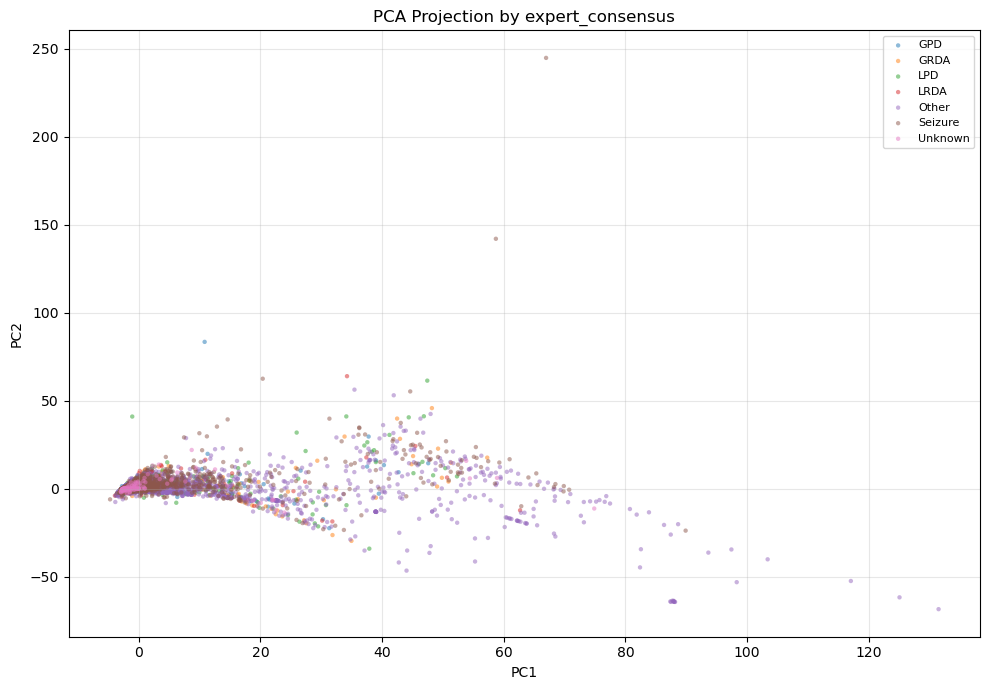

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ==============================
# 1. 데이터 로드
# ==============================
feature_df = pd.read_csv('/Users/pitzsb1/Desktop/NeuroStat/etc/feature_matrix.csv')
train_df = pd.read_csv('/Users/pitzsb1/Documents/HBAC/train.csv')

# ==============================
# 2. eeg_id별 대표 라벨 생성
# 여러 segment가 있을 수 있으므로 expert_consensus 다수결 사용
# ==============================
train_labels = (
    train_df.groupby('eeg_id')['expert_consensus']
    .agg(lambda x: x.value_counts().idxmax())
    .reset_index()
)

# ==============================
# 3. feature + label 병합
# ==============================
merged = feature_df.merge(train_labels, on='eeg_id', how='left')

# ==============================
# 4. X / y 분리
# ==============================
X = merged.drop(columns=['eeg_id', 'expert_consensus'])
y = merged['expert_consensus'].fillna('Unknown')

# ==============================
# 5. NaN 처리
# ==============================
print("NaN 개수:", X.isna().sum().sum())

imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)

# ==============================
# 6. Scaling
# PCA 전에 필수
# ==============================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# ==============================
# 7. PCA
# ==============================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("X_pca shape:", X_pca.shape)
print("labels shape:", y.shape)
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

# ==============================
# 8. PCA 시각화
# ==============================
unique_labels = np.unique(y)
colors = sns.color_palette('tab10', len(unique_labels))
label_to_color = {lab: colors[i] for i, lab in enumerate(unique_labels)}

plt.figure(figsize=(10, 7))

for lab in unique_labels:
    mask = y == lab
    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        s=10,
        alpha=0.5,
        color=label_to_color[lab],
        label=lab,
        edgecolors='none'
    )

plt.title('PCA Projection by expert_consensus')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(loc='best', fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

참고) 17,300 x 180(20 x 9 *autocorr 빠져서 10개 아님) 중 132,408(4.2%) 결측치

## 10. K-Means 클러스터링: k=6

처음에는 전문가 라벨 수가 6개이므로 `k=6`으로 클러스터링을 시도한다.  
목적은 모델이 라벨을 그대로 맞히는지보다, feature 공간에서 자연스럽게 묶이는 EEG 그룹이 있는지 확인하는 것이다.


In [59]:
# k-means (클러스터링)

from sklearn.cluster import KMeans

k = 6  # 일단 6 (라벨 개수 기준으로 시작)
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

clusters = kmeans.fit_predict(X_scaled)

### 10.1 PCA 공간에서 클러스터 시각화

K-Means가 만든 클러스터를 PCA 2차원 공간에 색으로 표시한다.  
클러스터가 명확히 분리되어 보이면 EEG feature가 특정 패턴 구조를 어느 정도 포착했다는 의미다.


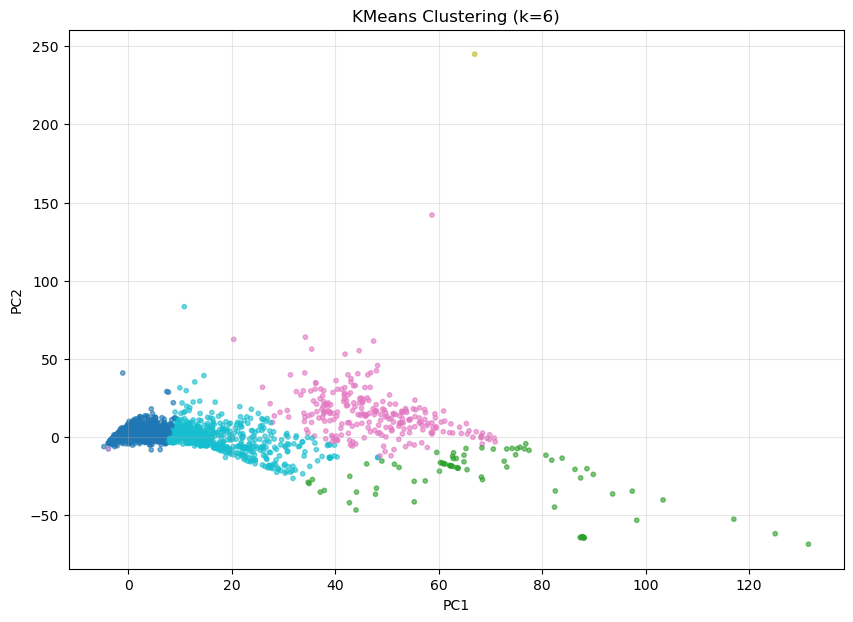

In [60]:
plt.figure(figsize=(10,7))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters,
    cmap='tab10',
    s=10,
    alpha=0.6
)

plt.title(f'KMeans Clustering (k={k})')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(alpha=0.3)
plt.show()

# 색깔이 덩어리처럼 나뉨 -> GOOD

### 10.2 Silhouette score 확인

Silhouette score는 클러스터 내부 응집도와 클러스터 간 분리도를 함께 보는 지표다.  
값이 높을수록 군집 구조가 비교적 뚜렷하다고 해석할 수 있다.


In [61]:
# 클러스터링 평가 (실루엣 점수)

from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, clusters)
print("Silhouette Score:", score)

Silhouette Score: 0.7756629047701056


### 10.3 클러스터와 전문가 라벨의 관계 확인

각 클러스터에 어떤 `expert_consensus` 라벨이 많이 들어갔는지 교차표로 확인한다.  
클러스터가 라벨과 완전히 일치하지 않더라도, 특정 라벨이 특정 클러스터에 몰리는지 보는 것이 중요하다.


In [62]:
merged['cluster'] = clusters

pd.crosstab(merged['cluster'], merged['expert_consensus'])

expert_consensus,GPD,GRDA,LPD,LRDA,Other,Seizure
cluster,,,,,,
0,1768,1776,2535,927,6578,2568
1,0,1,1,1,74,2
2,0,0,0,0,1,0
3,7,13,18,4,134,69
4,0,0,0,0,0,1
5,26,42,49,20,343,131


-> 클래스 분류는 잘 못 하는데, 이상 탐지는 잘함

## 11. Elbow method로 적절한 k 탐색

K-Means의 클러스터 수를 2부터 10까지 바꿔보며 inertia 변화를 확인한다.  
그래프에서 감소 폭이 급격히 줄어드는 지점이 적절한 k 후보가 된다.


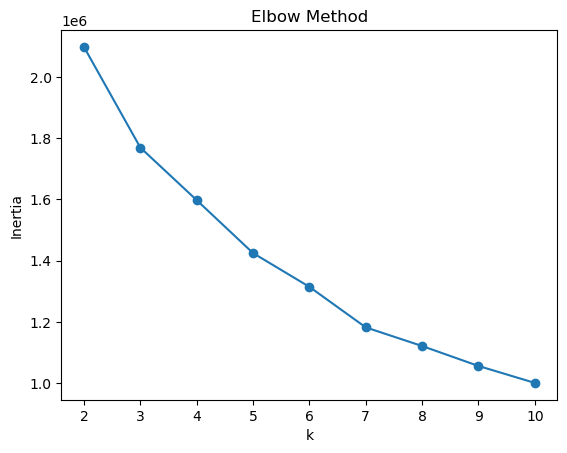

In [63]:
inertia = []

for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(range(2,11), inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.show()

-> k = 3일 때 꺾이는 지점. k 최적값

## 12. K-Means 클러스터링: k=3

Elbow plot에서 k=3이 적절해 보였기 때문에 클러스터 수를 3으로 줄여 다시 학습한다.  
이 단계는 EEG 데이터가 실제 라벨 6개보다 더 큰 구조에서는 3개의 패턴 덩어리로 나뉠 수 있는지 확인하는 과정이다.


In [64]:
# k-means

from sklearn.cluster import KMeans

k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

clusters = kmeans.fit_predict(X_scaled)

### 12.1 k=3 클러스터 시각화

PCA 공간에서 k=3 클러스터 결과를 다시 확인한다.  
k=6보다 단순한 구조로 데이터가 어떻게 나뉘는지 비교한다.


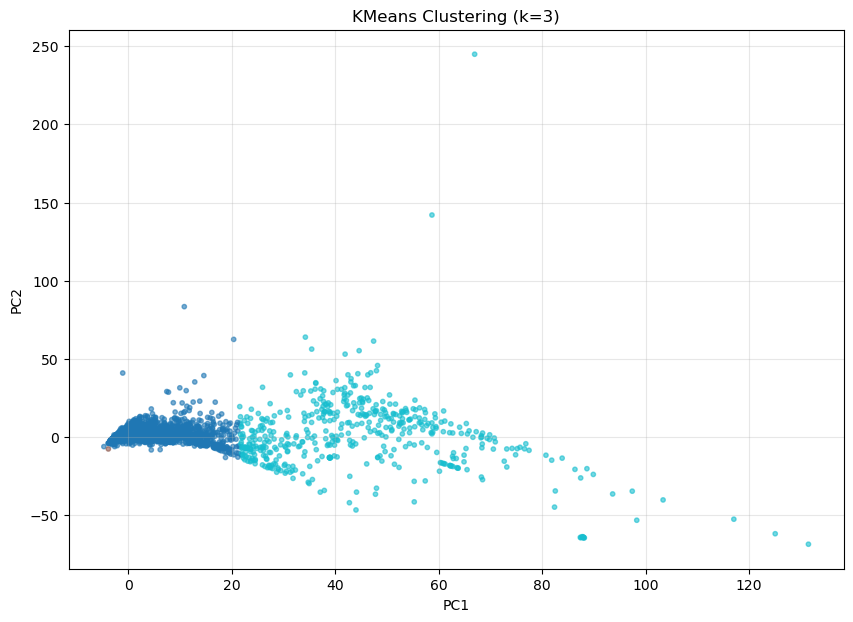

In [65]:
plt.figure(figsize=(10,7))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters,
    cmap='tab10',
    s=10,
    alpha=0.6
)

plt.title(f'KMeans Clustering (k={k})')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(alpha=0.3)
plt.show()

## 13. Isolation Forest 이상 탐지

K-Means가 전체적인 그룹 구조를 보는 방법이라면, Isolation Forest는 feature 공간에서 고립된 EEG 파일을 찾는 방법이다.  
`contamination=0.05`는 전체 데이터 중 약 5%를 이상치 후보로 보겠다는 의미다.


In [66]:
# isolation forest (이상 탐지)

from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    n_estimators=100,
    contamination=0.05,  # 상위 5%를 이상으로 가정
    random_state=42
)

anomaly_labels = iso.fit_predict(X_scaled)
anomaly_score = iso.decision_function(X_scaled)

# 결과 저장
merged['anomaly'] = anomaly_labels   # -1 = 이상, 1 = 정상
merged['score'] = anomaly_score

### 13.1 이상 점수 시각화

PCA 공간 위에 Isolation Forest의 anomaly score를 색으로 표시한다.  
색이 극단적인 영역은 일반적인 EEG feature 분포에서 벗어난 샘플일 가능성이 높다.


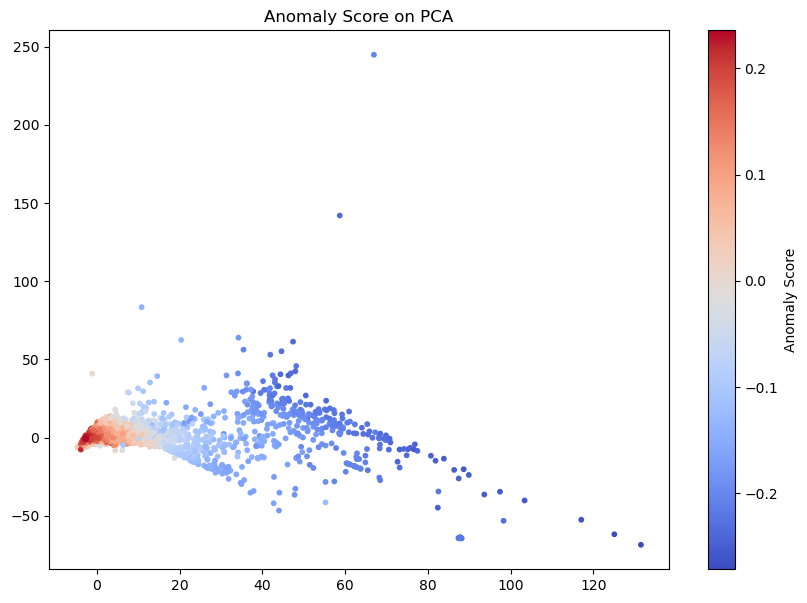

In [67]:
plt.figure(figsize=(10,7))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=anomaly_score,
    cmap='coolwarm',
    s=10
)

plt.colorbar(label='Anomaly Score')
plt.title('Anomaly Score on PCA')
plt.show()

# 점수 높음 -> 정상에 가까움
# 점수 낮음 -> 이상에 가까움

### 13.2 이상치 후보 목록 확인

Isolation Forest가 이상치로 판단한 EEG 파일을 추출한다.  
이후 실제 원본 파형을 열어보며 모델이 왜 이상치로 판단했는지 확인한다.


In [68]:
# 이상치 순위

outliers = merged[merged['anomaly'] == -1]

print(outliers[['eeg_id', 'score']].head())

        eeg_id     score
21  3945925489 -0.145070
30  1765478799 -0.235307
63  3268523216 -0.200827
88  1122434994 -0.061013
92  3279947709 -0.031186


## 14. 이상치 후보 원본 EEG 확인

이상 점수가 높은 EEG 파일을 직접 열어 특정 채널 파형을 확인한다.  
이 단계는 모델 결과를 숫자로만 보지 않고, 실제 신호 품질이나 artifact 여부와 연결해 해석하기 위한 검증 과정이다.


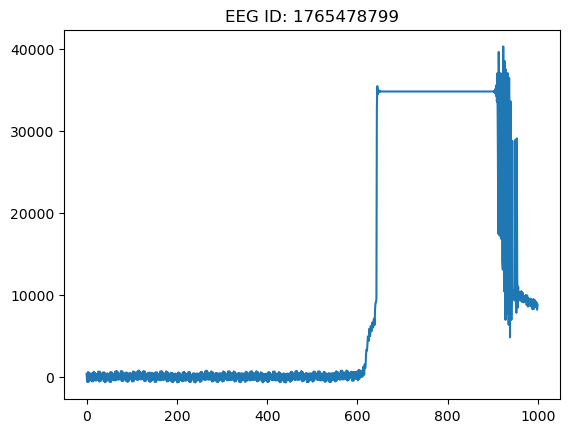

In [69]:
target_id = 1765478799  # 예시 (score 가장 낮은 것)

eeg = pd.read_parquet(f"/Users/pitzsb1/Documents/train_eegs/{target_id}.parquet")

plt.plot(eeg['Fz'][:1000])  # 일부 구간
plt.title(f"EEG ID: {target_id}")
plt.show()

-> EKG 떄문에 저렇게 그래프 튀는 건가?

### 14.1 채널 목록 확인

이상치 후보 파일에 어떤 채널이 포함되어 있는지 확인한다.  
특히 EKG 포함 여부나 채널 구성 이상이 있는지 점검한다.


In [70]:
print(eeg.columns)

Index(['Fp1', 'F3', 'C3', 'P3', 'F7', 'T3', 'T5', 'O1', 'Fz', 'Cz', 'Pz',
       'Fp2', 'F4', 'C4', 'P4', 'F8', 'T4', 'T6', 'O2', 'EKG'],
      dtype='str')


### 14.2 EKG 제외 후 파형 재확인

EKG가 신호를 크게 흔드는지 확인하기 위해 EKG를 제외하고 EEG 채널만 다시 그린다.  
그래도 비정상적으로 튀는 값이 남아 있다면 EEG 자체의 artifact 가능성이 높다.


<Axes: >

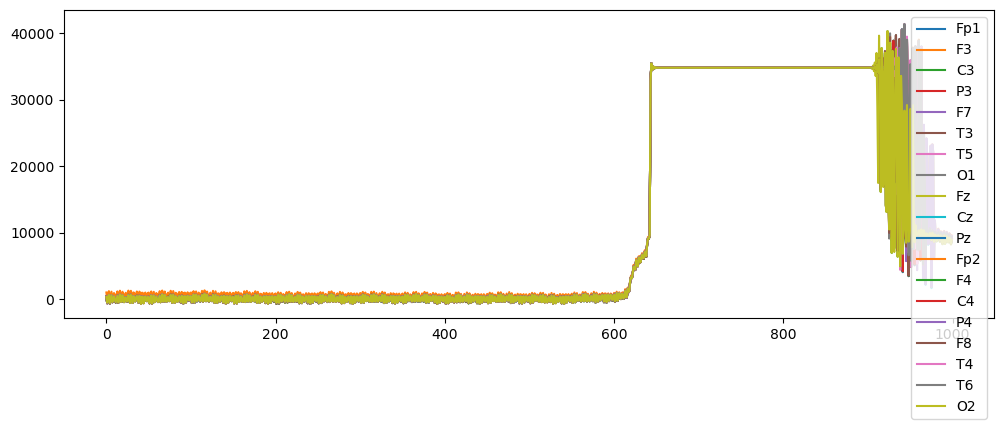

In [71]:
eeg.drop(columns=['EKG']).iloc[:1000].plot(figsize=(12,4))

-> 데이터가 깨진 거였음!

# NEW (데이터 정제 상태 변화... atifact)

## 15. Feature 추출 로직 개선: artifact 필터링

초기 이상치 후보 중 일부가 실제 뇌파 패턴이라기보다 데이터 품질 문제 또는 강한 artifact로 보였다.  
따라서 너무 큰 amplitude를 가진 파일을 제외하고, flat signal 처리 등을 포함해 feature matrix를 다시 생성한다.


In [72]:
import os
import pandas as pd
import numpy as np
from scipy.stats import skew, kurtosis
from joblib import Parallel, delayed
from tqdm import tqdm
import warnings

warnings.filterwarnings("ignore")

EEG_DIR = '/Users/pitzsb1/Documents/train_eegs/'
SAVE_PATH = '/Users/pitzsb1/Desktop/NeuroStat/etc/feature_clean_matrix.csv'

ARTIFACT_THRESHOLD = 1000   # 기존 5000보다 강하게
FLAT_STD_THRESHOLD = 1e-6

def is_artifact(eeg):
    values = eeg.values

    # 1. 값이 너무 큰 경우
    if np.nanmax(np.abs(values)) > ARTIFACT_THRESHOLD:
        return True

    # 2. 전체 변동성이 비정상적으로 큰 경우
    if np.nanstd(values) > ARTIFACT_THRESHOLD:
        return True

    # 3. NaN이 너무 많은 경우
    nan_ratio = np.isnan(values).mean()
    if nan_ratio > 0.1:
        return True

    return False


def process_file(fname):
    if not fname.endswith('.parquet'):
        return None
    
    eeg_id = int(fname.replace('.parquet', ''))
    
    try:
        eeg = pd.read_parquet(os.path.join(EEG_DIR, fname))

        # 🔥 artifact 제거
        if is_artifact(eeg):
            return None

        features = {}

        for ch in eeg.columns:
            sig = eeg[ch].values.astype(float)

            # NaN 보정
            if np.isnan(sig).any():
                sig = np.nan_to_num(sig, nan=np.nanmean(sig))

            mean = np.mean(sig)
            std  = np.std(sig)
            min_v = np.min(sig)
            max_v = np.max(sig)

            features[f'{ch}_mean'] = mean
            features[f'{ch}_std'] = std
            features[f'{ch}_min'] = min_v
            features[f'{ch}_max'] = max_v
            features[f'{ch}_range'] = max_v - min_v
            features[f'{ch}_absmean'] = np.mean(np.abs(sig))

            if std < FLAT_STD_THRESHOLD:
                skew_val = 0.0
                kurt_val = 0.0
                flat_flag = 1
            else:
                skew_val = skew(sig)
                kurt_val = kurtosis(sig)
                flat_flag = 0

            features[f'{ch}_skew'] = skew_val
            features[f'{ch}_kurtosis'] = kurt_val
            features[f'{ch}_flat'] = flat_flag

        features['eeg_id'] = eeg_id
        return features

    except Exception as e:
        print(f"Error in {fname}: {e}")
        return None


fnames = os.listdir(EEG_DIR)
n_jobs = max(1, os.cpu_count() - 1)

results = Parallel(n_jobs=n_jobs)(
    delayed(process_file)(fname) for fname in tqdm(fnames)
)

results = [r for r in results if r is not None]

feature_df = pd.DataFrame(results)
feature_df.to_csv(SAVE_PATH, index=False)

print(f"완료! Shape: {feature_df.shape}")
print(f"저장 위치: {SAVE_PATH}")

100%|██████████| 17300/17300 [00:56<00:00, 304.73it/s]


완료! Shape: (8739, 181)
저장 위치: /Users/pitzsb1/Desktop/NeuroStat/etc/feature_clean_matrix.csv


## 16. 정제된 feature matrix로 PCA 재수행

artifact 필터링 이후 새로 만든 feature matrix를 다시 불러와 결측치 처리, 표준화, PCA를 수행한다.  
이전 결과와 비교해 PCA 구조가 얼마나 안정적으로 유지되는지 확인한다.


In [73]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 데이터 로드
feature_df = pd.read_csv('/Users/pitzsb1/Desktop/NeuroStat/etc/feature_clean_matrix.csv')
train_df = pd.read_csv('/Users/pitzsb1/Documents/HBAC/train.csv')

# 라벨 처리
train_labels = (
    train_df.groupby('eeg_id')['expert_consensus']
    .agg(lambda x: x.value_counts().idxmax())
    .reset_index()
)

# merge
merged = feature_df.merge(train_labels, on='eeg_id', how='left')

# X, y
X = merged.drop(columns=['eeg_id', 'expert_consensus'])
y = merged['expert_consensus'].fillna('Unknown')

# NaN 처리
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)

# scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance:", pca.explained_variance_ratio_)
print("Total:", pca.explained_variance_ratio_.sum())

Explained variance: [0.34449746 0.10574435]
Total: 0.4502418115261153


### 16.1 PCA 설명 분산 비율 확인

PCA의 각 주성분이 전체 feature 분산을 얼마나 설명하는지 확인한다.  
상위 몇 개 주성분만으로도 누적 설명력이 충분하면, 고차원 EEG feature 구조를 낮은 차원에서 어느 정도 요약할 수 있다.


In [74]:
pca = PCA(n_components=3)
X_pca_3 = pca.fit_transform(X_scaled)
print(pca.explained_variance_ratio_)
print(pca.explained_variance_ratio_.cumsum())

[0.34449746 0.10574435 0.10519161]
[0.34449746 0.45024181 0.55543343]


### 16.2 라벨별 PCA 산점도

정제된 feature를 PCA 2차원에 투영하고, 전문가 라벨별로 색을 다르게 표시한다.  
라벨이 완전히 분리되지 않더라도, 특정 라벨이 어느 영역에 몰리는지 확인할 수 있다.


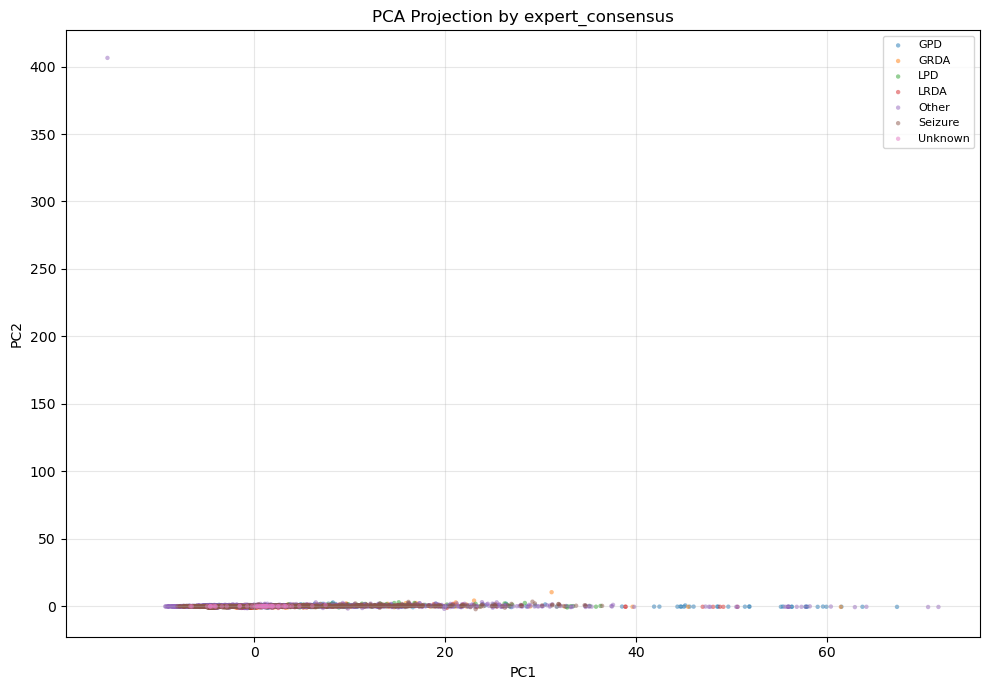

In [75]:
# pca

unique_labels = np.unique(y)
colors = sns.color_palette('tab10', len(unique_labels))
label_to_color = {lab: colors[i] for i, lab in enumerate(unique_labels)}
plt.figure(figsize=(10, 7))
for lab in unique_labels:
    mask = y == lab
    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        s=10,
        alpha=0.5,
        color=label_to_color[lab],
        label=lab,
        edgecolors='none'
    )

plt.title('PCA Projection by expert_consensus')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(loc='best', fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 17. 정제된 데이터에서 이상 탐지 재수행

artifact를 제거한 뒤 Isolation Forest를 다시 적용한다.  
이 단계의 목적은 단순한 데이터 깨짐이 아니라, feature 관점에서 여전히 특이한 EEG 파일을 찾는 것이다.


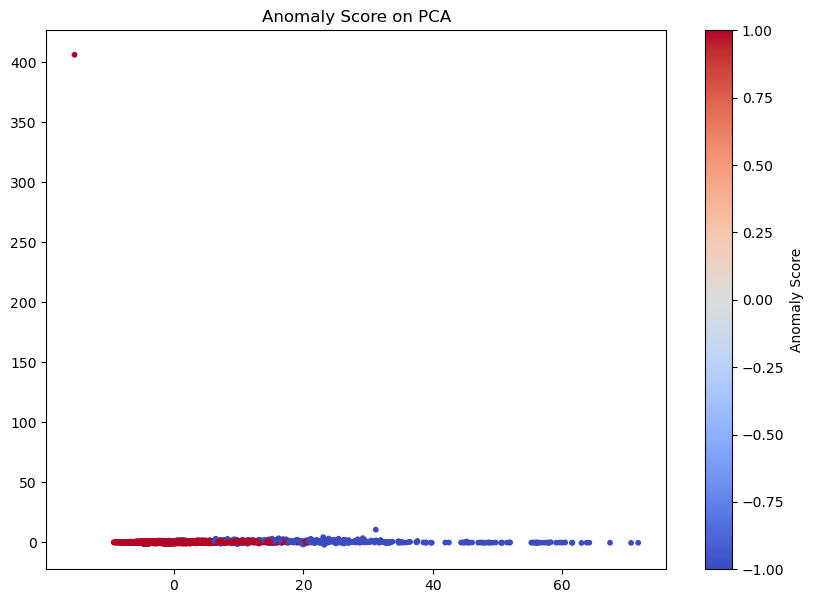

In [76]:
# isolation forest

iso = IsolationForest(contamination=0.05, random_state=42)
merged['score'] = iso.fit_predict(X_scaled)
plt.figure(figsize=(10,7))
plt.scatter(X_pca[:,0], X_pca[:,1], c=merged['score'], cmap='coolwarm', s=10)
plt.colorbar(label='Anomaly Score')
plt.title('Anomaly Score on PCA')
plt.show()

### 17.1 이상치 상위 후보 확인

정제 후에도 이상 점수가 높은 EEG 파일들을 정렬해 확인한다.  
이 목록은 이후 원본 EEG를 직접 열어보며 정상/비정상/아티팩트 여부를 검토할 후보군이다.


In [77]:
merged[['eeg_id','score']].sort_values('score').head(20)

,eeg_id,score
7679,1912374309,-1
5879,4157499200,-1
3142,278860386,-1
5396,3211529733,-1
5883,548975809,-1
3913,3783245182,-1
1479,2098263322,-1
5227,4141591240,-1
2818,2110516875,-1
6264,1804081759,-1


### 17.2 상위 이상치 후보 파형 비교

상위 anomaly 후보들의 원본 EEG 파형을 직접 시각화한다.  
여러 후보를 비교하면 공통적으로 나타나는 artifact 또는 이상 패턴이 있는지 확인할 수 있다.


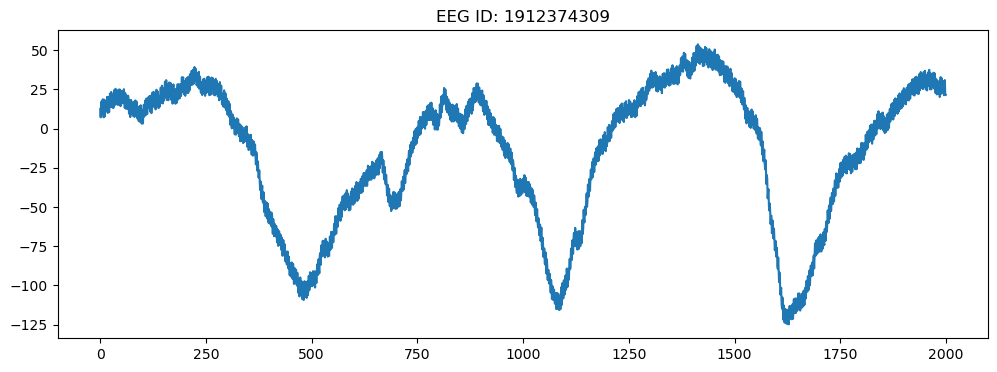

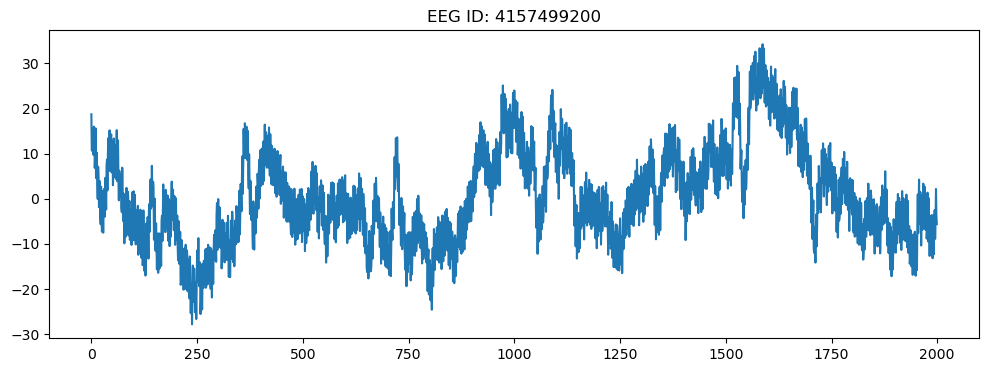

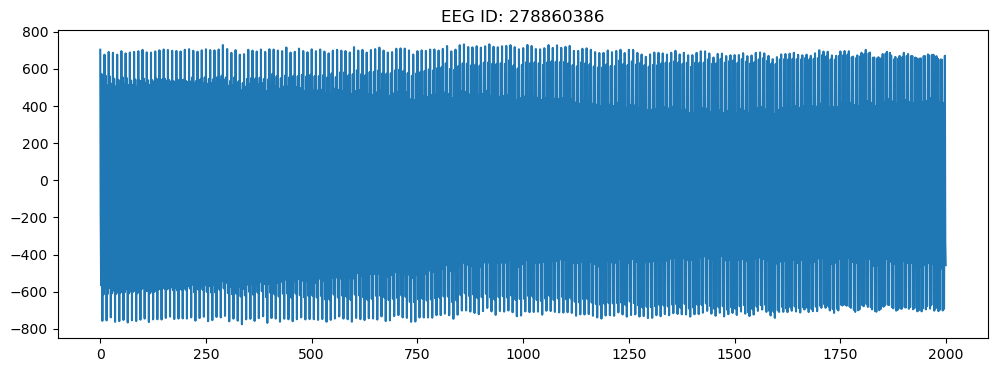

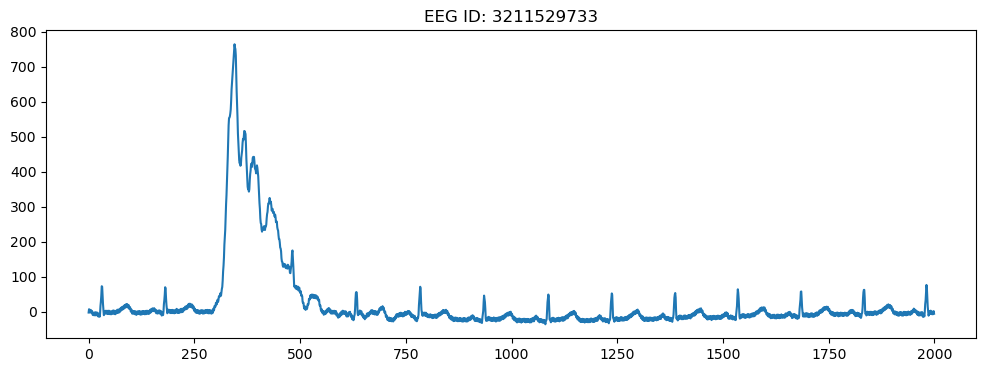

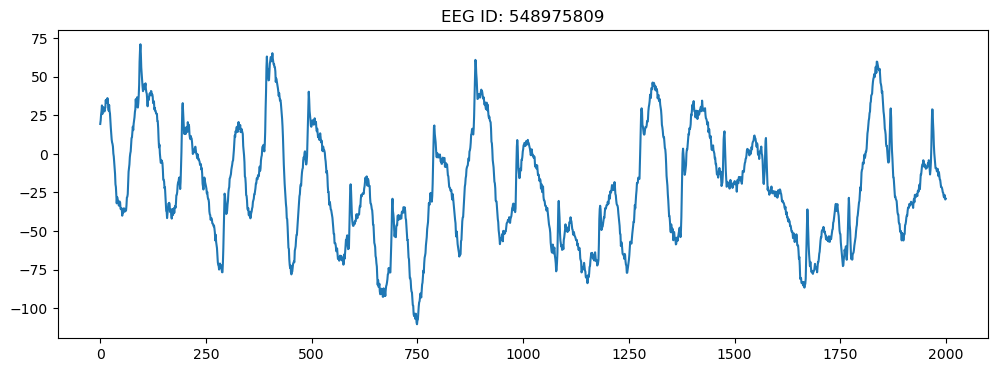

In [78]:
top_ids = [
1912374309, 4157499200, 278860386, 3211529733, 548975809,
3783245182, 2098263322, 4141591240, 2110516875, 1804081759
]

import pandas as pd
import matplotlib.pyplot as plt

for eid in top_ids[:5]:
    eeg = pd.read_parquet(f'/Users/pitzsb1/Documents/train_eegs/{eid}.parquet')

    plt.figure(figsize=(12,4))
    plt.plot(eeg['Fz'][:2000])
    plt.title(f"EEG ID: {eid}")
    plt.show()

## 18. EKG amplitude 분포 확인

EKG 채널의 최댓값 분포를 확인해, EKG가 전체 이상치 탐지 결과에 영향을 줄 가능성을 점검한다.  
이 결과는 EKG를 feature에 포함할지 제외할지 판단하는 근거가 된다.


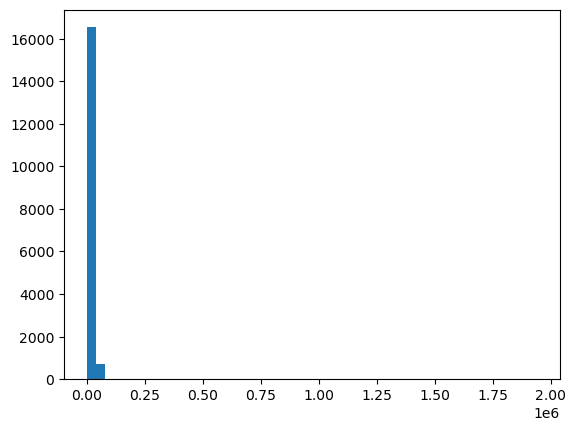

In [79]:
import os
import numpy as np
import pandas as pd

EEG_DIR = '/Users/pitzsb1/Documents/train_eegs/'
fnames = os.listdir(EEG_DIR)

# EKG max 분포 보기
ekg_max = []

for fname in fnames:
    eeg = pd.read_parquet(os.path.join(EEG_DIR, fname))
    ekg_max.append(np.max(np.abs(eeg['EKG'])))

import matplotlib.pyplot as plt
plt.hist(ekg_max, bins=50)
plt.show()